# Fase 1 + Fase 2: CNN Desde Cero (Optimizado para GPU local)

Este notebook implementa el entrenamiento de una red neuronal convolucional propia para la clasificación de 50 clases de landmarks. Está configurado para ejecutarse en una NVIDIA GeForce GTX 1050 Ti utilizando CUDA y precisión mixta (AMP).

1) Configuración del Entorno y Rutas

Definimos las rutas absolutas en el disco D: para evitar problemas de espacio en la unidad C: y asegurar que los scripts encuentren el dataset.

In [1]:
import os
import sys
from pathlib import Path

# Corrección: Agregamos \landmark-classifier al final
PROJECT_DIR = Path(r"D:\DESCARGAS\PYPAUL\proyecto_1\landmark-classifier")

# La ruta de los datos se mantiene igual (está un nivel arriba)
DATA_ROOT = Path(r"D:\DESCARGAS\PYPAUL\proyecto_1\Proyecto 1 Data set\landmark_images")

# Cambiar el directorio de trabajo al proyecto correcto
os.chdir(PROJECT_DIR)

print(f"Directorio del proyecto: {PROJECT_DIR}")
print(f"Ruta del dataset: {DATA_ROOT}")

# Verificación de carpetas críticas
assert DATA_ROOT.exists(), f"No se encontró el dataset en {DATA_ROOT}"
assert (PROJECT_DIR / "src").exists(), "No se encontró la carpeta 'src' con los scripts"

Directorio del proyecto: D:\DESCARGAS\PYPAUL\proyecto_1\landmark-classifier
Ruta del dataset: D:\DESCARGAS\PYPAUL\proyecto_1\Proyecto 1 Data set\landmark_images


2) Verificación de Hardware (CUDA)

Es vital confirmar que PyTorch está utilizando el ejecutable del entorno virtual .venv_cuda para acceder a la tarjeta de video.

In [2]:
import torch
import subprocess

print(f"Python ejecutable: {sys.executable}")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA disponible: {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"GPU detectada: {torch.cuda.get_device_name(0)}")
    # Mostrar estado de memoria de la GPU
    smi = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
    print(smi.stdout.splitlines()[0]) 
else:
    raise RuntimeError("CUDA no detectado. El entrenamiento sería demasiado lento en CPU.")

Python ejecutable: d:\DESCARGAS\PYPAUL\proyecto_1\landmark-classifier\.venv_cuda\Scripts\python.exe
PyTorch version: 2.5.1+cu121
CUDA disponible: True
GPU detectada: NVIDIA GeForce GTX 1050 Ti
Sat Apr 18 23:44:52 2026       


Celda 6: Markdown
3) Análisis Exploratorio (EDA)

Generamos estadísticas básicas y una muestra de las imágenes para validar que la carga de datos es correcta.

In [3]:
# Ejecutar el script de EDA
!{sys.executable} -m src.eda --data-root "{DATA_ROOT}" --out-dir outputs/eda --num-samples 6

{
  "train_images": 4996,
  "test_images": 1250,
  "num_classes": 50
}
EDA guardado en: outputs\eda


## 4) Entrenamiento de la CNN
Lanzamos el entrenamiento con los parámetros optimizados para superar el **40% de accuracy**:
* **LR 3e-4**: Para mayor estabilidad de aprendizaje.
* **AMP**: Precisión mixta para acelerar la GTX 1050 Ti.
* **Checkpoint every 5**: Para ahorrar espacio en disco duro.
* **Num Workers 4**: Para leer las imágenes rápido desde el HDD sin ahogar a la GPU.

In [4]:
import sys
import os

# Quitamos el truco de entorno porque Windows no lo soporta
if "PYTORCH_CUDA_ALLOC_CONF" in os.environ:
    del os.environ["PYTORCH_CUDA_ALLOC_CONF"]

# Hiperparámetros a prueba de fallos
EPOCHS = 35
BATCH_SIZE = 16  # Bocados mucho más pequeños y seguros
LR = "3e-4"
OUT_DIR = "outputs/final_run_gpu"
MODEL_PATH = "models/scratch_best_gpu.pt"

# Lanzamos el entrenamiento sin AMP
!{sys.executable} -u -m src.train \
    --data-root "{DATA_ROOT}" \
    --model-type scratch \
    --epochs {EPOCHS} \
    --batch-size {BATCH_SIZE} \
    --lr {LR} \
    --label-smoothing 0.1 \
    --use-cosine-scheduler \
    --num-workers 2 \
    --checkpoint-every 5 \
    --output-dir "{OUT_DIR}" \
    --export-path "{MODEL_PATH}"

device=cuda
cudnn_benchmark=enabled
amp=True
classes=50, train_batches=250
epoch=001 train_loss=3.8623 train_acc=0.0555 val_loss=3.6394 val_acc=0.1051
epoch=002 train_loss=3.6846 train_acc=0.0896 val_loss=3.5045 val_acc=0.1391
epoch=003 train_loss=3.6112 train_acc=0.1131 val_loss=3.3973 val_acc=0.1632
epoch=004 train_loss=3.5287 train_acc=0.1238 val_loss=3.3628 val_acc=0.1652
epoch=005 train_loss=3.4640 train_acc=0.1361 val_loss=3.3911 val_acc=0.1892
checkpoint_epoch=outputs\final_run_gpu\checkpoints\epoch_005.pth
epoch=006 train_loss=3.4044 train_acc=0.1561 val_loss=3.2802 val_acc=0.2062
epoch=007 train_loss=3.3319 train_acc=0.1821 val_loss=3.2090 val_acc=0.2302
epoch=008 train_loss=3.2583 train_acc=0.2039 val_loss=3.1148 val_acc=0.2392
epoch=009 train_loss=3.2077 train_acc=0.2152 val_loss=3.0552 val_acc=0.2553
epoch=010 train_loss=3.1449 train_acc=0.2297 val_loss=2.9776 val_acc=0.2803
checkpoint_epoch=outputs\final_run_gpu\checkpoints\epoch_010.pth
epoch=011 train_loss=3.0997 train_a

d:\DESCARGAS\PYPAUL\proyecto_1\landmark-classifier\src\train.py:240: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=use_amp) if device.type == "cuda" else None


## 5) Evaluación de Resultados
Cargamos las métricas generadas por el entrenamiento para verificar el cumplimiento de la rúbrica (Accuracy >= 40% y 30+ épocas).

--- RESUMEN DEL MODELO ---
Test Accuracy: 49.92%
Épocas completadas: 35
Mejor Época: 32
Dispositivo usado: cuda

Últimas épocas:


,epoch,train_loss,train_acc,val_loss,val_acc
30,31,2.500510,0.431073,2.460684,0.456456
31,32,2.510775,0.431574,2.429377,0.467467
32,33,2.507935,0.431323,2.429725,0.478478
33,34,2.506702,0.437828,2.436573,0.465465
34,35,2.492107,0.440831,2.434013,0.471471


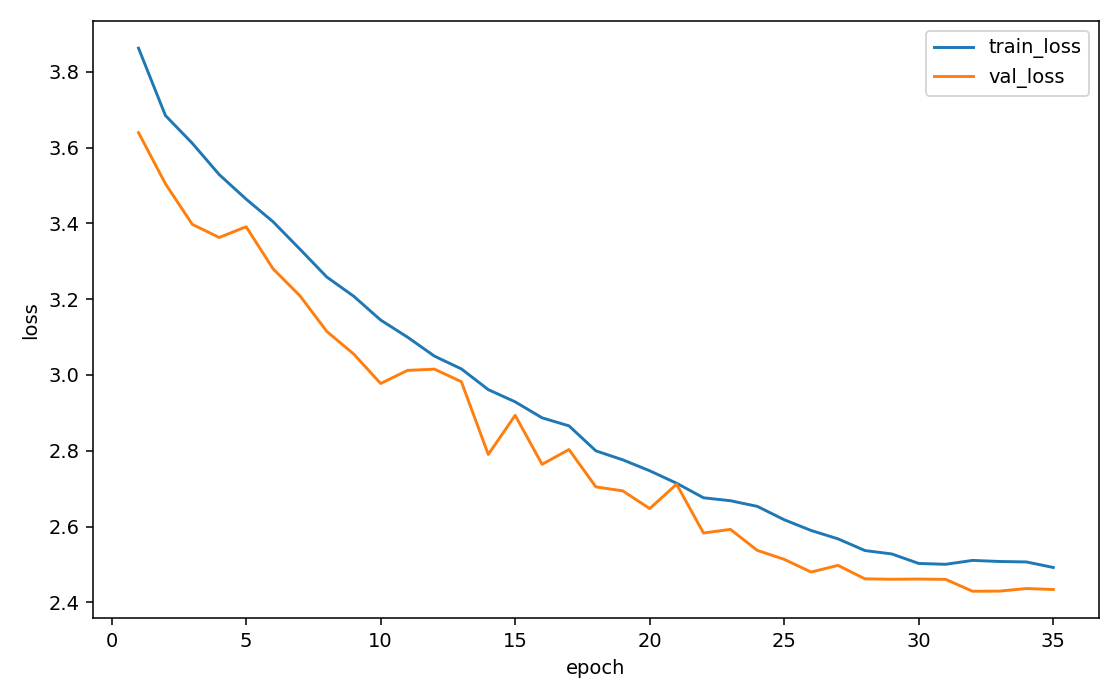

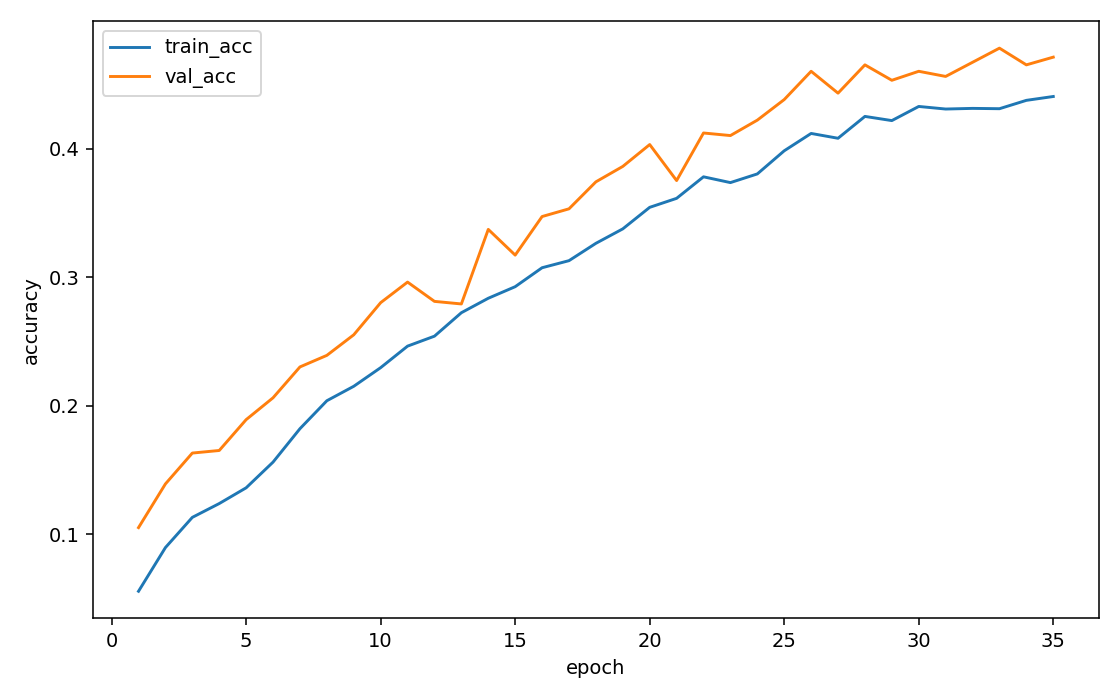


✅ ¡Objetivo alcanzado! El modelo supera el 40% de precisión.


In [5]:
import json
import pandas as pd
from IPython.display import Image, display

# Cargar resumen de métricas
with open(f"{OUT_DIR}/summary.json", "r") as f:
    summary = json.load(f)

print("--- RESUMEN DEL MODELO ---")
print(f"Test Accuracy: {summary['test_acc']:.2%}")
print(f"Épocas completadas: {summary['epochs']}")
print(f"Mejor Época: {summary.get('best_epoch', 'N/A')}")
print(f"Dispositivo usado: {summary['device']}")

# Mostrar métricas tabuladas (últimas 5 épocas)
metrics_df = pd.read_csv(f"{OUT_DIR}/metrics.csv")
print("\nÚltimas épocas:")
display(metrics_df.tail())

# Mostrar curvas de aprendizaje
try:
    display(Image(filename=f"{OUT_DIR}/loss_curve.png", width=600))
    display(Image(filename=f"{OUT_DIR}/accuracy_curve.png", width=600))
except FileNotFoundError:
    print("\n[Aviso] Los gráficos aún no se han generado o hubo un error al guardarlos.")

# Validación final
if summary['test_acc'] >= 0.40:
    print("\n✅ ¡Objetivo alcanzado! El modelo supera el 40% de precisión.")
else:
    print("\n❌ El modelo no alcanzó el 40%. Considera agregar más Data Augmentation en src.data.")

## 6) Verificación de Artefactos
Comprobamos que el modelo fue exportado correctamente en formato `TorchScript` para su despliegue, y revisamos que no hayamos saturado el disco con los checkpoints.

In [6]:
from pathlib import Path

export_path = Path(MODEL_PATH)
best_weights = Path(OUT_DIR) / "best_weights.pth"
checkpoints_dir = Path(OUT_DIR) / "checkpoints"

print(f"¿TorchScript exportado correctamente?: {export_path.exists()} ({export_path})")
print(f"¿Pesos de la mejor época guardados?: {best_weights.exists()}")

if checkpoints_dir.exists():
    checkpoints = sorted(checkpoints_dir.glob("*.pth"))
    print(f"Total de checkpoints intermedios (guardados cada 5 épocas): {len(checkpoints)}")
    if checkpoints:
        print(f"  - Último checkpoint guardado: {checkpoints[-1].name}")
else:
    print("No se encontró la carpeta de checkpoints.")

¿TorchScript exportado correctamente?: True (models\scratch_best_gpu.pt)
¿Pesos de la mejor época guardados?: True
Total de checkpoints intermedios (guardados cada 5 épocas): 7
  - Último checkpoint guardado: epoch_035.pth
